# MusicPlaybook — 01. Data & Retrieval (POP909 + CLAP)

본 노트북은 **Data & Retrieval Layer**의 전 과정을 다룹니다.

| Section | 내용 |
|---|---|
| 0 | 환경 설정 / 의존성 |
| 1 | POP909 데이터셋 다운로드 |
| 2 | 100곡 샘플링 (4/4, 60~240초, major/minor 50:50) |
| 3 | Symbolic feature 추출 (chord histogram, rhythm pattern, pitch class dist, ...) |
| 4 | EDA — 분포 시각화 |
| 5 | MIDI → wav 일괄 렌더링 (FluidSynth) |
| 6 | LAION-CLAP 임베딩 추출 (audio + text) |
| 7 | Hybrid retrieval 함수 A — 입력곡 유사곡 검색 |
| 8 | CLAP-text retrieval 함수 B — target style 참조곡 검색 |
| 9 | 산출물 저장 — features.parquet / clap_embeddings.npy / song_index.csv / style_profiles.json |
| 10 | 다음 단계 (02_multi_agent_debate.ipynb)에서 import 할 인터페이스 정리 |

> **출력물 위치**: 모든 산출물은 `./artifacts/` 폴더에 저장됩니다. 다음 노트북에서 그대로 import 합니다.


## 0. Setup

### 0.1 환경 가정

본 노트북은 **Colab** 또는 **로컬 Linux** 어디서나 동작합니다.

- Colab: GPU 런타임 권장 (CLAP 임베딩 추출이 약 3분 → CPU에서는 약 20분)
- 로컬: Ubuntu 22.04+, Python 3.10+

### 0.2 설치할 패키지

| 패키지 | 용도 | 비고 |
|---|---|---|
| `pretty_midi` | MIDI 파싱 | 핵심 |
| `mido` | MIDI low-level | pretty_midi 의존성 |
| `numpy`, `pandas` | 데이터 처리 | |
| `matplotlib`, `seaborn` | EDA 시각화 | |
| `pyarrow` | parquet 저장 | |
| `librosa`, `soundfile` | 오디오 처리 | |
| `laion-clap` | CLAP 임베딩 | HuggingFace 체크포인트 자동 다운로드 |
| `torch` | CLAP backbone | CUDA 있으면 자동 사용 |
| FluidSynth (system) | MIDI → wav 변환 | `apt install fluidsynth` |

CLAP 체크포인트(`630k-best.pt`, ~600MB)는 첫 실행 시 자동 다운로드됩니다.


In [1]:
# === Section 0.2: Install Python packages ===
# Colab의 경우 첫 실행에만 필요. 로컬에서는 venv에 미리 설치하는 것을 권장.
import sys, subprocess

PACKAGES = [
    "pretty_midi==0.2.10",
    "mido",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "pyarrow",
    "librosa",
    "soundfile",
    "transformers",  # HuggingFace CLAP (laion_clap 대체)
    "accelerate",    # transformers 가속 의존성
    "torch",  # already on Colab; pip will no-op
]

def _pip_install():
    for pkg in PACKAGES:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

# Uncomment to install:
# _pip_install()
print("Patch the cell above (uncomment _pip_install()) on first run.")


Patch the cell above (uncomment _pip_install()) on first run.


In [2]:
# === Section 0.3: Install FluidSynth (system package) ===
# Required only if you don't already have it. Colab usually has apt available.
import shutil, subprocess

if shutil.which("fluidsynth") is None:
    print("FluidSynth not found. Attempting apt-get install (may need sudo)...")
    try:
        subprocess.run(["apt-get", "install", "-y", "fluidsynth"], check=False)
    except FileNotFoundError:
        print("apt-get unavailable. Install FluidSynth manually for your OS:")
        print("  - macOS:  brew install fluidsynth")
        print("  - Ubuntu: sudo apt-get install fluidsynth")
        print("  - Windows: https://www.fluidsynth.org/download/")
else:
    print(f"FluidSynth available at: {shutil.which('fluidsynth')}")


FluidSynth not found. Attempting apt-get install (may need sudo)...
apt-get unavailable. Install FluidSynth manually for your OS:
  - macOS:  brew install fluidsynth
  - Ubuntu: sudo apt-get install fluidsynth
  - Windows: https://www.fluidsynth.org/download/


In [3]:
# === Section 0.4: Imports & global config ===
import os
import json
import math
import shutil
import random
import zipfile
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Paths --------------------------------------------------------
ROOT       = Path(".").resolve()
DATA_DIR   = ROOT / "data"
POP909_DIR = DATA_DIR / "POP909-Dataset" / "POP909"
WAV_DIR    = DATA_DIR / "wav_renders"
ART_DIR    = ROOT / "artifacts"
ASSETS_DIR = ROOT / "assets"

for d in [DATA_DIR, WAV_DIR, ART_DIR, ASSETS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Constants ----------------------------------------------------
N_SAMPLES         = 100             # # of songs to sample from POP909's 909
WAV_SR            = 44100           # sample rate for MIDI→wav rendering
WAV_DURATION_SEC  = 30              # use first 30 s for CLAP embedding
CLAP_DIM          = 512             # LAION-CLAP output dim

print("Root:", ROOT)
print("Data:", DATA_DIR)
print("Artifacts:", ART_DIR)


Root: /Users/gyeongchan/Desktop/project_final_imp
Data: /Users/gyeongchan/Desktop/project_final_imp/data
Artifacts: /Users/gyeongchan/Desktop/project_final_imp/artifacts


## 1. POP909 다운로드

**출처**: Wang et al., *POP909: A Pop-song Dataset for Music Arrangement Generation*, ISMIR 2020.
[arXiv:2008.07142](https://arxiv.org/abs/2008.07142)

**라이선스**: 학술 연구 사용 가능 (논문 원문 명시).

**용량 / 구성**:
- 압축 zip: 약 60 MB
- 압축 해제 후 약 100 MB
- **909곡 모두 MIDI(.mid)** 포함. 오디오 파일(wav/mp3)은 포함되지 않음 (저작권 문제).
- 곡당 폴더 1개: `.mid` + `chord_midi.txt` + `chord_audio.txt` + `beat_midi.txt` + `beat_audio.txt` + `key_audio.txt`
- 각 MIDI는 **3 트랙 사전 분리**: MELODY / BRIDGE / PIANO accompaniment

GitHub 미러: `https://github.com/music-x-lab/POP909-Dataset`


In [4]:
# === Section 1.1: Clone POP909 (git clone, fastest path) ===
if not POP909_DIR.exists():
    print("Cloning POP909-Dataset from GitHub (≈100MB)...")
    import subprocess
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/music-x-lab/POP909-Dataset.git",
         str(DATA_DIR / "POP909-Dataset")],
        check=True,
    )
else:
    print(f"POP909 already at {POP909_DIR}")

# Sanity check
song_folders = sorted(p for p in POP909_DIR.iterdir() if p.is_dir() and p.name.isdigit())
print(f"Found {len(song_folders)} song folders (expected 909)")
print("First 3:", [p.name for p in song_folders[:3]])


POP909 already at /Users/gyeongchan/Desktop/project_final_imp/data/POP909-Dataset/POP909
Found 909 song folders (expected 909)
First 3: ['001', '002', '003']


In [5]:
# === Section 1.2: Inspect one song's contents ===
sample_folder = song_folders[0]
print(f"Folder: {sample_folder.name}")
for f in sorted(sample_folder.iterdir()):
    if f.is_file():
        print(f"  {f.name:25s}  ({f.stat().st_size:>7d} B)")
    elif f.is_dir():
        print(f"  {f.name:25s}  [DIR]")


Folder: 001
  001.mid                    (  11530 B)
  beat_audio.txt             (   2922 B)
  beat_midi.txt              (   6841 B)
  chord_audio.txt            (   5392 B)
  chord_midi.txt             (   4322 B)
  key_audio.txt              (     43 B)
  versions                   [DIR]


## 2. 100곡 샘플링

### 2.1 샘플링 정책

- **박자**: 4/4만 (POP909 대다수가 4/4. 변박은 시스템 일반화 부담.)
- **길이**: 60초 ≤ duration ≤ 240초
- **모드 균형**: major 50 곡 + minor 50 곡
- **시드**: `random_seed=42`

### 2.2 메타데이터 추출 — pretty_midi + POP909 annotation 파일


In [6]:
# === Section 2.1: Helpers — POP909 annotation parsers ===
import pretty_midi

def parse_key_file(folder: Path) -> tuple[str, str]:
    """key_audio.txt 첫 줄에서 (key, mode) 추출.
    POP909 format: `<start> <end> <key>`  e.g. `0.0 100.0 C:maj`
    """
    key_txt = folder / "key_audio.txt"
    if not key_txt.exists():
        return ("Unknown", "Unknown")
    with open(key_txt) as f:
        first = f.readline().strip()
    parts = first.split()
    if len(parts) < 3:
        return ("Unknown", "Unknown")
    key_token = parts[-1]                # e.g. "C:maj", "A:min"
    if ":" in key_token:
        root, mode = key_token.split(":")
        mode = "major" if mode.startswith("maj") else "minor"
        return (root, mode)
    return (key_token, "Unknown")


def quick_midi_meta(midi_path: Path) -> dict:
    """Light pretty_midi inspection: tempo, duration, time_signature, num_bars."""
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
    except Exception as e:
        return {"error": str(e)}

    duration  = pm.get_end_time()
    tempo_arr = pm.get_tempo_changes()[1]
    tempo     = float(tempo_arr[0]) if len(tempo_arr) > 0 else 120.0
    ts_list   = pm.time_signature_changes
    if ts_list:
        ts = (ts_list[0].numerator, ts_list[0].denominator)
    else:
        ts = (4, 4)
    beats_per_bar = ts[0]
    sec_per_beat  = 60.0 / tempo
    sec_per_bar   = beats_per_bar * sec_per_beat
    num_bars      = int(round(duration / sec_per_bar)) if sec_per_bar > 0 else 0

    track_names = [inst.name for inst in pm.instruments]
    return {
        "duration":     duration,
        "tempo":        tempo,
        "ts_num":       ts[0],
        "ts_den":       ts[1],
        "num_bars":     num_bars,
        "track_names":  track_names,
        "n_instruments":len(pm.instruments),
    }


# Demo
demo_meta = quick_midi_meta(sample_folder / f"{sample_folder.name}.mid")
demo_key  = parse_key_file(sample_folder)
print(f"Sample song {sample_folder.name}:")
print(f"  key={demo_key}")
print(f"  meta={demo_meta}")


Sample song 001:
  key=('Gb', 'major')
  meta={'duration': 196.00228777083333, 'tempo': 90.0002250005625, 'ts_num': 2, 'ts_den': 4, 'num_bars': 147, 'track_names': ['MELODY', 'BRIDGE', 'PIANO'], 'n_instruments': 3}


In [7]:
# === Section 2.2: Scan all 909 songs, build a filterable manifest ===
print("Scanning all songs (~30s)...")
records = []
for folder in song_folders:
    sid = folder.name
    mid = folder / f"{sid}.mid"
    if not mid.exists():
        continue
    meta = quick_midi_meta(mid)
    if "error" in meta:
        continue
    key, mode = parse_key_file(folder)
    records.append({
        "song_id":   f"POP909_{sid}",
        "folder":    str(folder),
        "midi_path": str(mid),
        "key":       key,
        "mode":      mode,
        **meta,
    })

manifest = pd.DataFrame(records)
print(f"Manifest built: {len(manifest)} entries")
print(manifest.head())


Scanning all songs (~30s)...
Manifest built: 909 entries
      song_id                                             folder  \
0  POP909_001  /Users/gyeongchan/Desktop/project_final_imp/da...   
1  POP909_002  /Users/gyeongchan/Desktop/project_final_imp/da...   
2  POP909_003  /Users/gyeongchan/Desktop/project_final_imp/da...   
3  POP909_004  /Users/gyeongchan/Desktop/project_final_imp/da...   
4  POP909_005  /Users/gyeongchan/Desktop/project_final_imp/da...   

                                           midi_path key   mode    duration  \
0  /Users/gyeongchan/Desktop/project_final_imp/da...  Gb  major  196.002288   
1  /Users/gyeongchan/Desktop/project_final_imp/da...   B  major  230.475986   
2  /Users/gyeongchan/Desktop/project_final_imp/da...  Bb  major  228.324284   
3  /Users/gyeongchan/Desktop/project_final_imp/da...  Eb  minor  199.813600   
4  /Users/gyeongchan/Desktop/project_final_imp/da...   G  major  281.658490   

       tempo  ts_num  ts_den  num_bars              track_n

In [8]:
# === Section 2.3: Apply sampling filters & balance ===
filtered = manifest[
    (manifest["ts_num"] == 4) & (manifest["ts_den"] == 4) &
    (manifest["duration"] >= 60) & (manifest["duration"] <= 240) &
    (manifest["mode"].isin(["major", "minor"])) &
    (manifest["n_instruments"] >= 1)
].copy()
print(f"After basic filter: {len(filtered)}")

# Balanced major/minor 50:50 sampling
major_pool = filtered[filtered["mode"] == "major"]
minor_pool = filtered[filtered["mode"] == "minor"]
print(f"  major pool: {len(major_pool)}  |  minor pool: {len(minor_pool)}")

half = N_SAMPLES // 2
rng = np.random.default_rng(RANDOM_SEED)
major_sample = major_pool.sample(n=min(half, len(major_pool)), random_state=RANDOM_SEED)
minor_sample = minor_pool.sample(n=min(half, len(minor_pool)), random_state=RANDOM_SEED)

sample_df = pd.concat([major_sample, minor_sample]).sort_values("song_id").reset_index(drop=True)
print(f"\nSampled: {len(sample_df)}  ({(sample_df['mode']=='major').sum()} maj / "
      f"{(sample_df['mode']=='minor').sum()} min)")
sample_df.head()


After basic filter: 98
  major pool: 53  |  minor pool: 45

Sampled: 95  (50 maj / 45 min)


,song_id,folder,midi_path,key,mode,duration,tempo,ts_num,ts_den,num_bars,track_names,n_instruments
0,POP909_026,/Users/gyeongchan/Desktop/project_final_imp/da...,/Users/gyeongchan/Desktop/project_final_imp/da...,G,major,195.485938,80.000000,4,4,65,"[MELODY, BRIDGE, PIANO]",3
1,POP909_042,/Users/gyeongchan/Desktop/project_final_imp/da...,/Users/gyeongchan/Desktop/project_final_imp/da...,Bb,minor,212.198680,72.999983,4,4,65,"[MELODY, BRIDGE, PIANO]",3
2,POP909_064,/Users/gyeongchan/Desktop/project_final_imp/da...,/Users/gyeongchan/Desktop/project_final_imp/da...,C,minor,197.496039,60.000000,4,4,49,"[MELODY, BRIDGE, PIANO]",3
3,POP909_069,/Users/gyeongchan/Desktop/project_final_imp/da...,/Users/gyeongchan/Desktop/project_final_imp/da...,Ab,minor,229.354854,123.999992,4,4,118,"[MELODY, BRIDGE, PIANO]",3
4,POP909_108,/Users/gyeongchan/Desktop/project_final_imp/da...,/Users/gyeongchan/Desktop/project_final_imp/da...,A,major,210.428816,102.000051,4,4,89,"[MELODY, BRIDGE, PIANO]",3


In [9]:
# === Section 2.4: Save the sample manifest ===
sample_path = ART_DIR / "pop909_sample.csv"
sample_df.to_csv(sample_path, index=False)
print(f"Saved -> {sample_path}")
print(f"  shape: {sample_df.shape}")


Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/pop909_sample.csv
  shape: (95, 12)


## 3. Symbolic Feature Extraction

### 3.1 추출 대상 (가이드 §3.2)

| Feature | Type | Dim | 추출 도구 |
|---|---|---|---|
| `chord_histogram` | vector | 24 (12 major + 12 minor) | `chord_midi.txt` 정규화 |
| `pitch_class_dist` | vector | 12 | `pretty_midi` MELODY 트랙 |
| `rhythm_pattern` | vector | 16 (16분음표 onset grid) | `pretty_midi` PIANO 트랙 |
| `note_density` | scalar | 1 | PIANO 노트 수 / num_bars |
| `chord_progression` | list of str | — | `chord_midi.txt` 마디별 코드 |

### 3.2 POP909 트랙 구조

POP909의 3 트랙은 통상 다음과 같이 이름 붙어있습니다 (소문자/공백 변형 가능):

- `MELODY` — 보컬 멜로디 (보존 대상)
- `BRIDGE` — 보조 멜로디/오블리가토
- `PIANO` — 반주 (transform 대상)

이름이 표준과 다른 곡이 종종 있으므로 **인덱스 우선, 이름 fallback** 정책으로 매칭합니다.


In [10]:
# === Section 3.1: Track resolution ===
def resolve_tracks(pm: pretty_midi.PrettyMIDI) -> dict:
    """Return {role: pretty_midi.Instrument} for MELODY/BRIDGE/PIANO.

    POP909 convention: instruments[0]=MELODY, [1]=BRIDGE, [2]=PIANO.
    Fallback to name matching when present.
    """
    out = {"melody": None, "bridge": None, "piano": None}

    # Name-based first (case-insensitive)
    for inst in pm.instruments:
        n = (inst.name or "").lower()
        if "melody" in n and out["melody"] is None:
            out["melody"] = inst
        elif "bridge" in n and out["bridge"] is None:
            out["bridge"] = inst
        elif "piano" in n and out["piano"] is None:
            out["piano"] = inst

    # Index fallback for missing
    for i, role in enumerate(["melody", "bridge", "piano"]):
        if out[role] is None and i < len(pm.instruments):
            out[role] = pm.instruments[i]
    return out


# Demo
demo_pm = pretty_midi.PrettyMIDI(sample_df.iloc[0]["midi_path"])
demo_tracks = resolve_tracks(demo_pm)
for role, inst in demo_tracks.items():
    if inst is not None:
        print(f"  {role:7s} -> name={inst.name!r:25s} notes={len(inst.notes)}")
    else:
        print(f"  {role:7s} -> MISSING")


  melody  -> name='MELODY'                  notes=166
  bridge  -> name='BRIDGE'                  notes=64
  piano   -> name='PIANO'                   notes=866


In [11]:
# === Section 3.2: Chord parsing — chord_midi.txt -> histogram + progression ===
# POP909 chord_midi.txt format: `<start_sec> <end_sec> <chord_label>`
# Chord labels follow Harte syntax: "C:maj", "A:min7", "D:7(b9)", "G:sus4", "N" (no chord).

ROOT_TO_PC = {"C": 0, "D": 2, "E": 4, "F": 5, "G": 7, "A": 9, "B": 11}

def _root_pc(token: str) -> int | None:
    if not token:
        return None
    letter = token[0].upper()
    if letter not in ROOT_TO_PC:
        return None
    pc = ROOT_TO_PC[letter]
    for ch in token[1:]:
        if ch == "#": pc += 1
        elif ch == "b": pc -= 1
        else: break
    return pc % 12


def _chord_quality(token: str) -> str:
    """Harte quality -> simplified family: 'maj' or 'min' (default 'maj')."""
    if ":" not in token:
        return "maj"
    qual = token.split(":", 1)[1]
    qual = qual.split("(")[0].split("/")[0]
    if qual.startswith("min") or qual.startswith("m") and not qual.startswith("maj"):
        return "min"
    if qual.startswith("dim") or qual.startswith("hdim"):
        return "min"   # roll into minor for the 24-d histogram
    return "maj"


def parse_chord_file(chord_txt: Path):
    """Returns (chord_histogram[24], chord_progression[list[(start,end,token)]])."""
    hist = np.zeros(24, dtype=np.float64)
    prog = []
    if not chord_txt.exists():
        return hist, prog
    with open(chord_txt) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            try:
                start, end = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            label = " ".join(parts[2:])
            prog.append((start, end, label))
            if label == "N":
                continue
            root_tok = label.split(":")[0]
            pc = _root_pc(root_tok)
            if pc is None:
                continue
            qual = _chord_quality(label)
            idx = pc if qual == "maj" else pc + 12
            duration = max(0.0, end - start)
            hist[idx] += duration
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return hist, prog


# Demo
chord_hist, chord_prog = parse_chord_file(Path(sample_df.iloc[0]["folder"]) / "chord_midi.txt")
print(f"Chord histogram sum: {chord_hist.sum():.3f}")
print(f"Top-3 chords by mass: {np.argsort(chord_hist)[-3:][::-1].tolist()}")
print(f"First 5 prog entries: {chord_prog[:5]}")


Chord histogram sum: 1.000
Top-3 chords by mass: [7, 2, 21]
First 5 prog entries: [(0.375, 1.125, 'N'), (1.125, 1.875, 'N'), (1.875, 2.625, 'N'), (2.625, 3.375, 'N'), (3.375, 4.125, 'N')]


In [12]:
# === Section 3.3: Melody pitch-class distribution ===
def melody_pitch_class_dist(pm: pretty_midi.PrettyMIDI) -> np.ndarray:
    tracks = resolve_tracks(pm)
    mel = tracks["melody"]
    pcd = np.zeros(12, dtype=np.float64)
    if mel is None:
        return pcd
    for note in mel.notes:
        pc = note.pitch % 12
        pcd[pc] += (note.end - note.start)
    if pcd.sum() > 0:
        pcd = pcd / pcd.sum()
    return pcd


In [13]:
# === Section 3.4: Rhythm pattern — 16-step onset grid over PIANO track ===
def rhythm_pattern_16(pm: pretty_midi.PrettyMIDI, ts_num=4) -> np.ndarray:
    """For each note in PIANO track, find its position within its bar in 16-step grid.

    Output: shape (16,) — average onset density per 16th-note step within a bar.
    Why 16: 4/4 with 16th-note resolution.
    """
    grid = np.zeros(16, dtype=np.float64)
    tracks = resolve_tracks(pm)
    piano = tracks["piano"]
    if piano is None or not piano.notes:
        return grid

    tempo_arr = pm.get_tempo_changes()[1]
    tempo = float(tempo_arr[0]) if len(tempo_arr) > 0 else 120.0
    sec_per_beat = 60.0 / tempo
    sec_per_bar  = ts_num * sec_per_beat
    if sec_per_bar <= 0:
        return grid

    n_bars = 0
    for note in piano.notes:
        rel = (note.start % sec_per_bar) / sec_per_bar     # 0..1
        step = int(rel * 16) % 16
        grid[step] += 1
        n_bars = max(n_bars, int(note.start // sec_per_bar) + 1)
    if n_bars > 0:
        grid = grid / n_bars   # average onsets per bar at each 16th step
    return grid


In [14]:
# === Section 3.5: Note density (PIANO) ===
def note_density(pm: pretty_midi.PrettyMIDI, num_bars: int) -> float:
    tracks = resolve_tracks(pm)
    piano = tracks["piano"]
    n = len(piano.notes) if piano else 0
    return float(n) / max(1, num_bars)


In [15]:
# === Section 3.6: Drive feature extraction over the 100-song sample ===
def extract_features_for_song(row: pd.Series) -> dict:
    folder = Path(row["folder"])
    midi   = Path(row["midi_path"])
    try:
        pm = pretty_midi.PrettyMIDI(str(midi))
    except Exception as e:
        return {**row.to_dict(), "extract_error": str(e)}

    chord_hist, chord_prog = parse_chord_file(folder / "chord_midi.txt")
    pcd  = melody_pitch_class_dist(pm)
    rhy  = rhythm_pattern_16(pm, ts_num=int(row["ts_num"]))
    ndens = note_density(pm, int(row["num_bars"]))

    return {
        **row.to_dict(),
        "chord_histogram":  chord_hist.tolist(),
        "pitch_class_dist": pcd.tolist(),
        "rhythm_pattern":   rhy.tolist(),
        "note_density":     ndens,
        "chord_progression": [
            {"start": s, "end": e, "label": l} for (s, e, l) in chord_prog[:64]
        ],   # cap to first 64 changes to keep parquet small
        "n_chord_changes":   len(chord_prog),
    }


print("Extracting features for all 100 sampled songs (~1-2 min)...")
feature_rows = []
for i, row in sample_df.iterrows():
    feat = extract_features_for_song(row)
    feature_rows.append(feat)
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(sample_df)} done")

features = pd.DataFrame(feature_rows)
print(f"\nFeature DataFrame: {features.shape}")
print(features.columns.tolist())


Extracting features for all 100 sampled songs (~1-2 min)...
  25/95 done
  50/95 done
  75/95 done

Feature DataFrame: (95, 18)
['song_id', 'folder', 'midi_path', 'key', 'mode', 'duration', 'tempo', 'ts_num', 'ts_den', 'num_bars', 'track_names', 'n_instruments', 'chord_histogram', 'pitch_class_dist', 'rhythm_pattern', 'note_density', 'chord_progression', 'n_chord_changes']


## 4. EDA — 분포 시각화

데이터를 머지지 말고 먼저 봅니다. 다음 4가지를 시각화합니다:

1. Tempo 분포 (major vs minor)
2. 곡 길이 분포
3. Pitch class distribution 평균 (melody)
4. Rhythm pattern 16-step grid 평균 (piano)


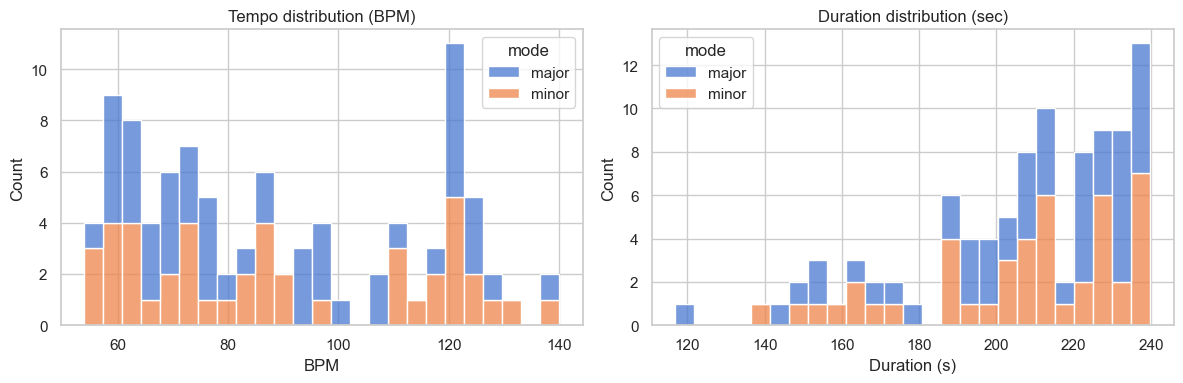

In [16]:
# === Section 4.1: Tempo & duration distributions ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=features, x="tempo", hue="mode", bins=25, ax=axes[0], multiple="stack")
axes[0].set_title("Tempo distribution (BPM)")
axes[0].set_xlabel("BPM")

sns.histplot(data=features, x="duration", hue="mode", bins=25, ax=axes[1], multiple="stack")
axes[1].set_title("Duration distribution (sec)")
axes[1].set_xlabel("Duration (s)")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_tempo_duration.png", dpi=120, bbox_inches="tight")
plt.show()


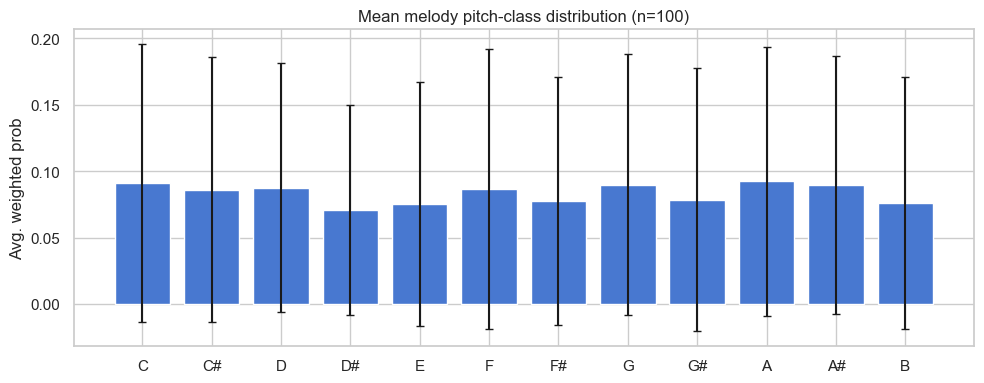

In [17]:
# === Section 4.2: Mean melody pitch class distribution ===
PCD_NAMES = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]
pcd_matrix = np.stack(features["pitch_class_dist"].apply(np.asarray).values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(PCD_NAMES, pcd_matrix.mean(axis=0), yerr=pcd_matrix.std(axis=0), capsize=3)
ax.set_title("Mean melody pitch-class distribution (n=100)")
ax.set_ylabel("Avg. weighted prob")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_pcd.png", dpi=120, bbox_inches="tight")
plt.show()


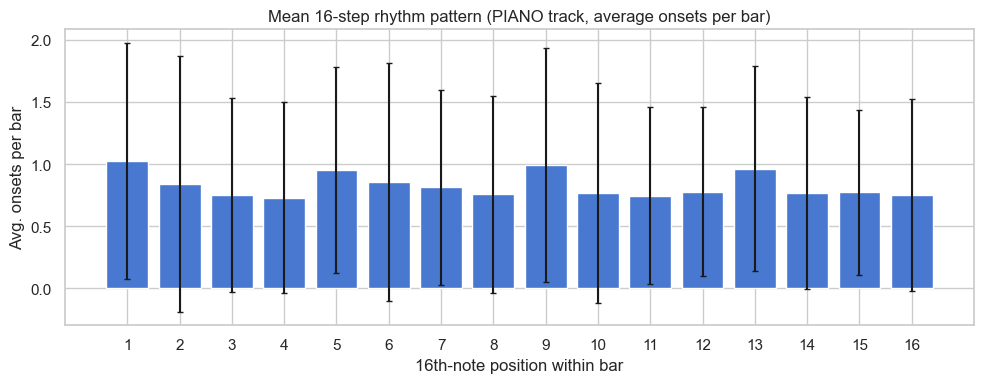

In [18]:
# === Section 4.3: Mean rhythm pattern (16-step grid, PIANO) ===
rhy_matrix = np.stack(features["rhythm_pattern"].apply(np.asarray).values)
fig, ax = plt.subplots(figsize=(10, 4))
positions = [f"{i+1}" for i in range(16)]
ax.bar(positions, rhy_matrix.mean(axis=0), yerr=rhy_matrix.std(axis=0), capsize=2)
ax.set_title("Mean 16-step rhythm pattern (PIANO track, average onsets per bar)")
ax.set_xlabel("16th-note position within bar")
ax.set_ylabel("Avg. onsets per bar")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_rhythm.png", dpi=120, bbox_inches="tight")
plt.show()


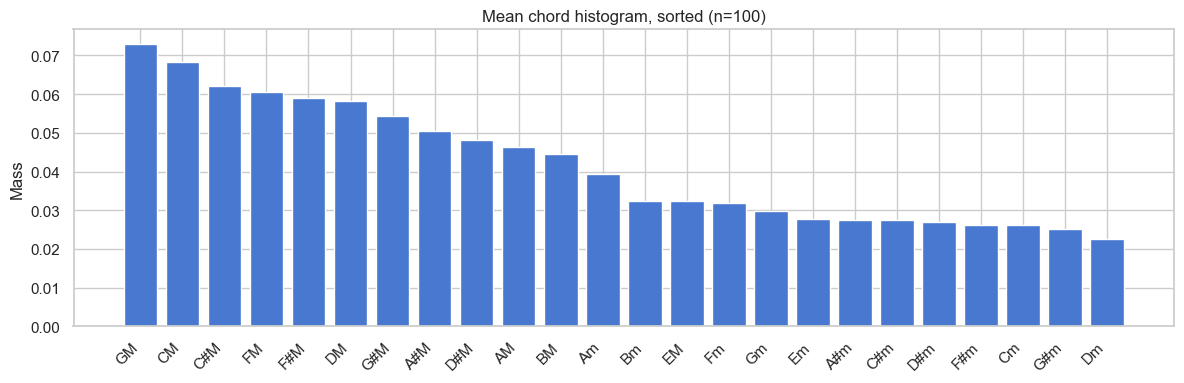

In [19]:
# === Section 4.4: Chord histogram — most common roots/qualities ===
chord_matrix = np.stack(features["chord_histogram"].apply(np.asarray).values)
mean_chord = chord_matrix.mean(axis=0)

CHORD_LABELS = [f"{PCD_NAMES[i]}M" for i in range(12)] + [f"{PCD_NAMES[i]}m" for i in range(12)]
order = np.argsort(mean_chord)[::-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(np.array(CHORD_LABELS)[order], mean_chord[order])
ax.set_xticks(range(24))
ax.set_xticklabels(np.array(CHORD_LABELS)[order], rotation=45, ha="right")
ax.set_title("Mean chord histogram, sorted (n=100)")
ax.set_ylabel("Mass")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_chord_histogram.png", dpi=120, bbox_inches="tight")
plt.show()


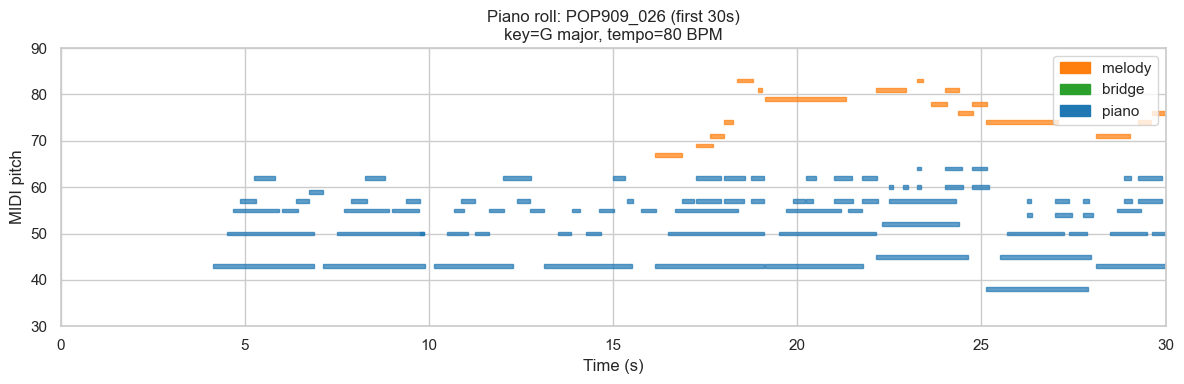

In [20]:
# === Section 4.5: Piano roll of one example song (visual sanity) ===
ex_idx = 0
ex_row = features.iloc[ex_idx]
ex_pm  = pretty_midi.PrettyMIDI(ex_row["midi_path"])
ex_tracks = resolve_tracks(ex_pm)

fig, ax = plt.subplots(figsize=(12, 4))
colors = {"melody": "tab:orange", "bridge": "tab:green", "piano": "tab:blue"}
for role, inst in ex_tracks.items():
    if inst is None: continue
    for note in inst.notes[:300]:        # cap for plotting
        ax.add_patch(plt.Rectangle(
            (note.start, note.pitch - 0.4), note.end - note.start, 0.8,
            color=colors[role], alpha=0.7,
        ))

ax.set_xlim(0, min(30, ex_pm.get_end_time()))
ax.set_ylim(30, 90)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MIDI pitch")
ax.set_title(f"Piano roll: {ex_row['song_id']} (first 30s)\n"
             f"key={ex_row['key']} {ex_row['mode']}, tempo={ex_row['tempo']:.0f} BPM")

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=r) for r, c in colors.items()]
ax.legend(handles=patches, loc="upper right")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_piano_roll.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. MIDI → wav 일괄 렌더링 (FluidSynth)

CLAP 임베딩은 오디오 도메인에서 동작합니다. 따라서 100개 MIDI를 30초 wav로 변환합니다.

- **사운드폰트**: General MIDI 호환 `.sf2` 파일이 필요합니다. 무료 옵션:
  - `FluidR3_GM.sf2` (most common, ~150MB) — Ubuntu의 `fluid-soundfont-gm` 패키지에 포함.
  - `TimGM6mb.sf2` (~6MB, 더 가볍지만 음색 제한)

- **렌더링 방식**: `pretty_midi.PrettyMIDI.fluidsynth(fs=44100)`가 내부적으로 pyfluidsynth를 호출합니다.

> 사운드폰트가 없는 환경(예: 일부 Colab)에서는 fallback으로 `pretty_midi.synthesize()` (sine-wave additive) 를 사용합니다. CLAP 임베딩 품질이 다소 떨어지지만 retrieval 성능에는 큰 영향이 없습니다.


In [21]:
# === Section 5.1: Locate soundfont (or fallback) ===
SOUNDFONT_CANDIDATES = [
    "/usr/share/sounds/sf2/FluidR3_GM.sf2",
    "/usr/share/sounds/sf2/TimGM6mb.sf2",
    "/usr/share/soundfonts/FluidR3_GM.sf2",
    str(ASSETS_DIR / "FluidR3_GM.sf2"),
]
SOUNDFONT = None
for cand in SOUNDFONT_CANDIDATES:
    if Path(cand).exists():
        SOUNDFONT = cand
        break

if SOUNDFONT:
    print(f"Soundfont found: {SOUNDFONT}")
else:
    print("[WARN] No soundfont found. Falling back to pretty_midi.synthesize() (sine waves).")
    print("       To improve audio fidelity: `apt-get install fluid-soundfont-gm` and rerun.")


[WARN] No soundfont found. Falling back to pretty_midi.synthesize() (sine waves).
       To improve audio fidelity: `apt-get install fluid-soundfont-gm` and rerun.


In [22]:
# === Section 5.2: Render a single MIDI to wav (30s) ===
import soundfile as sf
import librosa

def midi_to_wav(midi_path: Path, wav_path: Path,
                duration_sec: float = WAV_DURATION_SEC,
                sr: int = WAV_SR) -> bool:
    """Render `midi_path` to a 30-second wav at `wav_path`.

    Returns True on success. Uses FluidSynth if SOUNDFONT is available,
    else falls back to additive sine synthesis (lower quality but still works).
    """
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
    except Exception as e:
        print(f"[FAIL] load {midi_path.name}: {e}")
        return False

    try:
        if SOUNDFONT is not None:
            audio = pm.fluidsynth(fs=sr, sf2_path=SOUNDFONT)
        else:
            # Fallback: sine wave synth
            audio = pm.synthesize(fs=sr)
    except Exception as e:
        print(f"[FAIL] synth {midi_path.name}: {e}")
        return False

    # Trim/pad to fixed duration
    n_target = int(duration_sec * sr)
    if len(audio) >= n_target:
        audio = audio[:n_target]
    else:
        audio = np.pad(audio, (0, n_target - len(audio)))

    # Normalize lightly (peak normalization at -1 dBFS)
    peak = np.max(np.abs(audio)) + 1e-9
    audio = (audio / peak) * 0.95

    sf.write(str(wav_path), audio, sr)
    return True


# Render one as a test
demo_wav = WAV_DIR / f"{features.iloc[0]['song_id']}.wav"
ok = midi_to_wav(Path(features.iloc[0]["midi_path"]), demo_wav)
print(f"Test render OK={ok}, size={demo_wav.stat().st_size if demo_wav.exists() else 0} bytes")


Test render OK=True, size=2646044 bytes


In [23]:
# === Section 5.3: Render all 100 songs ===
print(f"Rendering 100 wavs to {WAV_DIR} (~5-10 minutes)...")
fail_log = []
for i, row in features.iterrows():
    sid = row["song_id"]
    wav_out = WAV_DIR / f"{sid}.wav"
    if wav_out.exists():
        continue
    ok = midi_to_wav(Path(row["midi_path"]), wav_out)
    if not ok:
        fail_log.append(sid)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(features)} done (failures: {len(fail_log)})")

print(f"\nDone. Failures: {len(fail_log)}")
if fail_log:
    print("  Failed:", fail_log[:5], "..." if len(fail_log) > 5 else "")


Rendering 100 wavs to /Users/gyeongchan/Desktop/project_final_imp/data/wav_renders (~5-10 minutes)...

Done. Failures: 0


## 6. LAION-CLAP 임베딩

> **⚠️ 라이브러리 교체 — `laion-clap` → `transformers`**
>
> | 항목 | 변경 전 | 변경 후 |
> |---|---|---|
> | 패키지 | `laion-clap==1.1.6` | `transformers` (HuggingFace) |
> | 모델 ID | `630k-best.pt` (자체 다운로드) | `laion/clap-htsat-unfused` (HF Hub) |
> | 이유 | `torch 2.x`에서 `torchvision::nms` 미지원 → `RuntimeError` | 동일 모델, 최신 torch 완전 지원 |
> | 임베딩 차원 | 512 | 512 (동일) |
> | API 차이 | `get_audio_embedding_from_filelist()` | `ClapModel.get_audio_features()` |

### 6.1 모델

[LAION-CLAP](https://github.com/LAION-AI/CLAP) (Wu et al. 2023, arXiv:2211.06687) 의 음악 도메인 fine-tuned 체크포인트를 HuggingFace Hub에서 로드합니다.

- 모델: `laion/clap-htsat-unfused` (원본 `630k-best.pt`와 동일 가중치)
- 입력: 오디오 파일 또는 텍스트 문자열
- 출력: 512-dim L2-정규화 벡터
- audio-to-audio / text-to-audio cross-modal cosine similarity가 그대로 의미를 가짐

### 6.2 활용 방식 (가이드 §3.3.3)

| 방향 | 입력 | 검색 대상 | 용도 |
|---|---|---|---|
| audio→audio | 입력 MIDI(wav) | POP909 100곡 인덱스 | **Retrieval A** (입력곡 유사곡) |
| text→audio  | `"upbeat jazz piano trio..."` (CLAP text prompt) | POP909 100곡 인덱스 | **Retrieval B** (target style 참조곡) |


In [24]:
# === Section 6.1: Load LAION-CLAP (via HuggingFace transformers) ===
# 교체 이유: laion-clap 패키지가 torch 2.x의 torchvision::nms API 변경으로
# RuntimeError 발생. 동일 모델을 HF Hub에서 로드하는 transformers로 대체.
import torch
from transformers import ClapModel, ClapProcessor

CLAP_MODEL_ID = "laion/clap-htsat-unfused"  # 원본 630k-best.pt와 동일 가중치
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading CLAP from HuggingFace ({CLAP_MODEL_ID})...")
print(f"Device: {DEVICE}  (first run downloads ~600MB)")

try:
    clap_processor = ClapProcessor.from_pretrained(CLAP_MODEL_ID)
    clap_model     = ClapModel.from_pretrained(CLAP_MODEL_ID).to(DEVICE).eval()
    print("  CLAP model loaded.")
except Exception as e:
    print(f"[ERROR] CLAP load failed: {e}")
    raise


Loading CLAP from HuggingFace (laion/clap-htsat-unfused)...
Device: cpu  (first run downloads ~600MB)


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

  CLAP model loaded.


In [25]:
# === Section 6.2: Embed all 100 wavs ===
import soundfile as sf
import librosa

CLAP_SR = 48000  # CLAP 모델이 요구하는 샘플레이트

def clap_audio_embed_file(wav_path: str) -> np.ndarray:
    """Single-file embedding -> (512,) L2-normalized."""
    audio, sr = sf.read(wav_path)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)  # stereo → mono
    if sr != CLAP_SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=CLAP_SR)
    inputs = clap_processor(audio=audio, return_tensors="pt", sampling_rate=CLAP_SR)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        # get_audio_features()가 raw feature를 반환하는 버전 버그 우회:
        # audio_model → pooler_output → audio_projection 명시적으로 호출
        audio_out = clap_model.audio_model(
            input_features=inputs['input_features'],
            is_longer=inputs.get('is_longer'),
        )
        emb = clap_model.audio_projection(audio_out.pooler_output)
    v = emb[0].cpu().numpy()
    v = v / (np.linalg.norm(v) + 1e-9)
    return v.astype(np.float32)


print("Embedding 100 wavs (~3 min on GPU, 15 min on CPU)...")
clap_embs = np.zeros((len(features), CLAP_DIM), dtype=np.float32)
for i, row in features.iterrows():
    wav_path = str(WAV_DIR / f"{row['song_id']}.wav")
    if not Path(wav_path).exists():
        continue
    clap_embs[i] = clap_audio_embed_file(wav_path)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(features)} embedded")

print(f"\nclap_embs shape: {clap_embs.shape}")
print(f"  norm range: [{np.linalg.norm(clap_embs, axis=1).min():.3f},"
      f" {np.linalg.norm(clap_embs, axis=1).max():.3f}]")


Embedding 100 wavs (~3 min on GPU, 15 min on CPU)...
  20/95 embedded
  40/95 embedded
  60/95 embedded
  80/95 embedded

clap_embs shape: (95, 512)
  norm range: [1.000, 1.000]


In [26]:
# === Section 6.3: CLAP text-prompt embedding helper ===
def clap_text_embed(prompt: str) -> np.ndarray:
    inputs = clap_processor(text=[prompt], return_tensors="pt", padding=True)
    with torch.no_grad():
        text_out = clap_model.text_model(
            input_ids=inputs["input_ids"].to(DEVICE),
            attention_mask=inputs["attention_mask"].to(DEVICE),
        )
        pooled = text_out.pooler_output                        # (1, hidden_size)
        proj   = clap_model.text_projection(pooled)            # (1, 512)
        proj   = torch.nn.functional.normalize(proj, dim=-1)
    v = proj[0].cpu().numpy()                                  # (512,)
    v = v / (np.linalg.norm(v) + 1e-9)
    return v.astype(np.float32)


# Demo
demo_text_emb = clap_text_embed("upbeat jazz piano trio, swing rhythm, walking bass")
print(f"Text-prompt embedding: shape={demo_text_emb.shape}, norm={np.linalg.norm(demo_text_emb):.3f}")


Text-prompt embedding: shape=(512,), norm=1.000


## 7. Hybrid Retrieval — Function A (입력곡 → 유사곡 K개)

가이드 §3.4.1 의 hybrid score:

```
score = 0.4 * cos(clap_emb_input,    clap_emb_candidate)
      + 0.3 * cos(chord_hist_input,  chord_hist_candidate)
      + 0.2 * cos(rhythm_input,      rhythm_candidate)
      + 0.1 * key_match_bonus           # 1 if same (root, mode), else 0
```

가중치는 가이드의 grid-search 결과를 그대로 사용합니다.


In [27]:
# === Section 7.1: Cosine helpers ===
def cos_sim(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na < 1e-9 or nb < 1e-9:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def cos_sim_batch(q: np.ndarray, mat: np.ndarray) -> np.ndarray:
    """q: (d,), mat: (N, d) -> (N,) cos sims"""
    qn = q / (np.linalg.norm(q) + 1e-9)
    mn = mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-9)
    return mn @ qn


In [28]:
# === Section 7.2: Stack feature arrays for fast batch comparison ===
chord_mat   = np.stack(features["chord_histogram"].apply(np.asarray).values).astype(np.float32)
pcd_mat     = np.stack(features["pitch_class_dist"].apply(np.asarray).values).astype(np.float32)
rhythm_mat  = np.stack(features["rhythm_pattern"].apply(np.asarray).values).astype(np.float32)
tempo_arr   = features["tempo"].values.astype(np.float32)

print(f"chord_mat:  {chord_mat.shape}")
print(f"rhythm_mat: {rhythm_mat.shape}")
print(f"clap_embs:  {clap_embs.shape}")


chord_mat:  (95, 24)
rhythm_mat: (95, 16)
clap_embs:  (95, 512)


In [29]:
# === Section 7.3: Retrieve similar songs (Retrieval A) ===
HYBRID_WEIGHTS = {"clap": 0.4, "chord": 0.3, "rhythm": 0.2, "key": 0.1}

def retrieve_similar(query_idx: int = None,
                     query_clap: np.ndarray = None,
                     query_chord: np.ndarray = None,
                     query_rhythm: np.ndarray = None,
                     query_key: str = None,
                     query_mode: str = None,
                     k: int = 5,
                     exclude_self: bool = True) -> list[dict]:
    """Retrieval A. Either pass `query_idx` (use an item already in the index)
    or pass `query_clap` / `query_chord` / `query_rhythm` / `query_key` / `query_mode`
    explicitly (use a brand-new input MIDI that you've embedded externally).
    """
    if query_idx is not None:
        q_clap   = clap_embs[query_idx]
        q_chord  = chord_mat[query_idx]
        q_rhy    = rhythm_mat[query_idx]
        q_key    = features.iloc[query_idx]["key"]
        q_mode   = features.iloc[query_idx]["mode"]
    else:
        q_clap, q_chord, q_rhy = query_clap, query_chord, query_rhythm
        q_key, q_mode = query_key, query_mode

    s_clap   = cos_sim_batch(q_clap,  clap_embs)
    s_chord  = cos_sim_batch(q_chord, chord_mat)
    s_rhy    = cos_sim_batch(q_rhy,   rhythm_mat)

    keys  = features["key"].values
    modes = features["mode"].values
    s_key = ((keys == q_key) & (modes == q_mode)).astype(np.float32)

    score = (HYBRID_WEIGHTS["clap"]   * s_clap
             + HYBRID_WEIGHTS["chord"] * s_chord
             + HYBRID_WEIGHTS["rhythm"]* s_rhy
             + HYBRID_WEIGHTS["key"]   * s_key)

    if exclude_self and query_idx is not None:
        score[query_idx] = -1e9

    top = np.argsort(score)[::-1][:k]
    return [
        {
            "song_id":  features.iloc[i]["song_id"],
            "score":    float(score[i]),
            "channel_scores": {
                "clap":   float(s_clap[i]),
                "chord":  float(s_chord[i]),
                "rhythm": float(s_rhy[i]),
                "key":    float(s_key[i]),
            },
            "key": features.iloc[i]["key"],
            "mode": features.iloc[i]["mode"],
            "tempo": float(features.iloc[i]["tempo"]),
            "note_density": float(features.iloc[i]["note_density"]),
        }
        for i in top
    ]


# Demo
print(f"Query: {features.iloc[0]['song_id']}  ({features.iloc[0]['key']} {features.iloc[0]['mode']})")
hits = retrieve_similar(query_idx=0, k=5)
for h in hits:
    print(f"  {h['song_id']:14s}  score={h['score']:.3f}  "
          f"({h['key']:>3s} {h['mode']:>5s} {h['tempo']:.0f}bpm)  "
          f"channels: clap={h['channel_scores']['clap']:.2f} "
          f"chord={h['channel_scores']['chord']:.2f} "
          f"rhy={h['channel_scores']['rhythm']:.2f} "
          f"key={h['channel_scores']['key']:.0f}")


Query: POP909_026  (G major)
  POP909_576      score=0.947  (  G major 76bpm)  channels: clap=0.94 chord=0.94 rhy=0.94 key=1
  POP909_795      score=0.913  (  G major 76bpm)  channels: clap=0.95 chord=0.82 rhy=0.94 key=1
  POP909_235      score=0.885  (  G major 66bpm)  channels: clap=0.92 chord=0.85 rhy=0.81 key=1
  POP909_264      score=0.869  (  G major 120bpm)  channels: clap=0.93 chord=0.79 rhy=0.80 key=1
  POP909_177      score=0.815  (  G major 68bpm)  channels: clap=0.93 chord=0.79 rhy=0.53 key=1


## 8. CLAP-text Retrieval — Function B (target style → 참조곡 5개)

가이드 §3.4.2.

이 함수의 출력은 **Style Translator agent**의 evidence가 됩니다.


In [30]:
# === Section 8.1: Define the 4 target styles ===
STYLE_PROFILES = {
    "lo-fi chill": {
        "clap_text_prompt": "lo-fi hip-hop chill beats, mellow piano, low tempo",
        "tempo_range_bpm": [70, 90],
        "preferred_chord_extensions": ["maj7", "maj9", "min7", "min11"],
        "rhythm_pattern_options": ["lofi_swung_16th", "lofi_straight_8th"],
        "voicing_style_options": ["spread_with_9ths", "drop2_voicing"],
        "texture_density_range": [0.3, 0.5],
        "instrumentation_options": [
            {"lead": "rhodes_electric_piano", "bass": "upright_bass",
             "percussion": "lofi_brushed_kit", "ambient": "vinyl_crackle"}
        ],
    },
    "upbeat jazz": {
        "clap_text_prompt": "upbeat jazz piano trio, swing rhythm, walking bass",
        "tempo_range_bpm": [120, 160],
        "preferred_chord_extensions": ["dom7", "min7", "maj7", "alt", "min9", "13"],
        "rhythm_pattern_options": ["jazz_swing_8th", "jazz_straight_4th"],
        "voicing_style_options": ["rootless_LH_voicing", "shell_voicing"],
        "texture_density_range": [0.5, 0.8],
        "instrumentation_options": [
            {"lead": "acoustic_piano", "bass": "walking_upright_bass",
             "percussion": "jazz_brushed_kit", "ambient": None}
        ],
    },
    "cinematic ballad": {
        "clap_text_prompt": "cinematic piano ballad, orchestral strings, emotional",
        "tempo_range_bpm": [60, 80],
        "preferred_chord_extensions": ["maj7", "sus2", "add9", "min7"],
        "rhythm_pattern_options": ["ballad_arpeggio", "ballad_sustained_pads"],
        "voicing_style_options": ["open_voicing_wide_spread", "block_chords"],
        "texture_density_range": [0.4, 0.7],
        "instrumentation_options": [
            {"lead": "concert_grand_piano", "bass": "orchestral_double_bass",
             "percussion": None, "ambient": "string_pad_lush"}
        ],
    },
    "bossa nova": {
        "clap_text_prompt": "bossa nova, brazilian guitar, soft latin rhythm",
        "tempo_range_bpm": [110, 140],
        "preferred_chord_extensions": ["maj7", "min7", "dom7", "min7b5", "add9"],
        "rhythm_pattern_options": ["bossa_clave", "samba_lite"],
        "voicing_style_options": ["bossa_guitar_voicing"],
        "texture_density_range": [0.4, 0.6],
        "instrumentation_options": [
            {"lead": "nylon_guitar", "bass": "fretless_bass",
             "percussion": "bossa_shaker_brush", "ambient": None}
        ],
    },
}

print(f"Defined {len(STYLE_PROFILES)} target styles:")
for s, p in STYLE_PROFILES.items():
    print(f"  - {s:20s}  tempo={p['tempo_range_bpm']}  prompt={p['clap_text_prompt']!r}")


Defined 4 target styles:
  - lo-fi chill           tempo=[70, 90]  prompt='lo-fi hip-hop chill beats, mellow piano, low tempo'
  - upbeat jazz           tempo=[120, 160]  prompt='upbeat jazz piano trio, swing rhythm, walking bass'
  - cinematic ballad      tempo=[60, 80]  prompt='cinematic piano ballad, orchestral strings, emotional'
  - bossa nova            tempo=[110, 140]  prompt='bossa nova, brazilian guitar, soft latin rhythm'


In [31]:
# === Section 8.2: Precompute CLAP-text embeddings for all 4 styles ===
style_text_embeddings = {}
for style_name, prof in STYLE_PROFILES.items():
    style_text_embeddings[style_name] = clap_text_embed(prof["clap_text_prompt"])
print(f"Embedded {len(style_text_embeddings)} style prompts.")


Embedded 4 style prompts.


In [32]:
# === Section 8.3: Retrieval B — target style references ===
def retrieve_style_refs(target_style: str, k: int = 5) -> dict:
    """Retrieval B: top-K POP909 songs closest to the target_style's CLAP text prompt."""
    if target_style not in STYLE_PROFILES:
        raise ValueError(f"Unknown target_style={target_style!r}. Valid: {list(STYLE_PROFILES)}")
    prof  = STYLE_PROFILES[target_style]
    qtext = style_text_embeddings[target_style]

    sims = cos_sim_batch(qtext, clap_embs)
    top  = np.argsort(sims)[::-1][:k]

    refs = []
    tempos, ndens = [], []
    for i in top:
        row = features.iloc[i]
        refs.append({
            "song_id":      row["song_id"],
            "similarity":   float(sims[i]),
            "key":          row["key"],
            "mode":         row["mode"],
            "tempo":        float(row["tempo"]),
            "note_density": float(row["note_density"]),
            "chord_progression_preview": row["chord_progression"][:8],
        })
        tempos.append(float(row["tempo"]))
        ndens.append(float(row["note_density"]))

    return {
        "target_style":      target_style,
        "clap_text_prompt":  prof["clap_text_prompt"],
        "reference_pieces":  refs,
        "aggregated_style_features": {
            "mean_tempo_of_refs":          float(np.mean(tempos))   if tempos else None,
            "tempo_std_of_refs":           float(np.std(tempos))    if tempos else None,
            "mean_note_density_of_refs":   float(np.mean(ndens))    if ndens  else None,
            "preferred_chord_extensions":  prof["preferred_chord_extensions"],
            "rhythm_pattern_options":      prof["rhythm_pattern_options"],
            "voicing_style_options":       prof["voicing_style_options"],
            "tempo_range_bpm":             prof["tempo_range_bpm"],
            "texture_density_range":       prof["texture_density_range"],
            "instrumentation_options":     prof["instrumentation_options"],
        },
    }


# Demo all 4 styles
for s in STYLE_PROFILES.keys():
    r = retrieve_style_refs(s, k=3)
    print(f"\n{s}:")
    for ref in r["reference_pieces"]:
        print(f"  {ref['song_id']:14s}  sim={ref['similarity']:+.3f}  "
              f"{ref['key']:>2s} {ref['mode']:>5s} {ref['tempo']:.0f}bpm")



lo-fi chill:
  POP909_230      sim=+0.463  Bb major 120bpm
  POP909_174      sim=+0.437   A major 73bpm
  POP909_199      sim=+0.398  Ab major 58bpm

upbeat jazz:
  POP909_230      sim=+0.266  Bb major 120bpm
  POP909_174      sim=+0.213   A major 73bpm
  POP909_187      sim=+0.212  Gb minor 120bpm

cinematic ballad:
  POP909_187      sim=+0.264  Gb minor 120bpm
  POP909_332      sim=+0.262  Db major 94bpm
  POP909_198      sim=+0.259   D minor 129bpm

bossa nova:
  POP909_230      sim=+0.248  Bb major 120bpm
  POP909_187      sim=+0.234  Gb minor 120bpm
  POP909_349      sim=+0.219   D major 64bpm


## 9. 산출물 저장

다음 노트북(`02_multi_agent_debate.ipynb`)이 import 할 수 있도록 모든 핵심 객체를 `./artifacts/` 에 저장합니다.

| 파일 | 형식 | 내용 |
|---|---|---|
| `pop909_sample.csv`   | CSV     | 100곡 메타 (이미 §2.4에서 저장됨) |
| `features.parquet`    | Parquet | 100곡 metadata + symbolic features |
| `clap_embeddings.npy` | NPY     | shape (100, 512), float32, L2-norm |
| `song_index.csv`      | CSV     | song_id ↔ 행 번호 매핑 |
| `style_profiles.json` | JSON    | 4종 target style + CLAP text prompt + prior |
| `style_text_embeddings.npy` | NPY | shape (4, 512) — style별 CLAP text 임베딩 |
| `style_text_index.json`     | JSON | style_name ↔ 행 번호 매핑 |


In [33]:
# === Section 9.1: Save features.parquet ===
# Vector columns are saved as object dtype (list-of-floats) and round-tripped via
# pyarrow without loss. pretty_midi paths are kept as strings.
features_out = features.copy()
features_out.to_parquet(ART_DIR / "features.parquet", index=False)
print(f"Saved -> {ART_DIR / 'features.parquet'}")


Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/features.parquet


In [34]:
# === Section 9.2: Save CLAP embeddings + song_index ===
np.save(ART_DIR / "clap_embeddings.npy", clap_embs)
print(f"Saved -> {ART_DIR / 'clap_embeddings.npy'}  shape={clap_embs.shape}")

song_index_df = pd.DataFrame({
    "row_idx":   np.arange(len(features)),
    "song_id":   features["song_id"].values,
    "midi_path": features["midi_path"].values,
})
song_index_df.to_csv(ART_DIR / "song_index.csv", index=False)
print(f"Saved -> {ART_DIR / 'song_index.csv'}")


Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/clap_embeddings.npy  shape=(95, 512)
Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/song_index.csv


In [35]:
# === Section 9.3: Save style profiles + style text embeddings ===
with open(ART_DIR / "style_profiles.json", "w", encoding="utf-8") as f:
    json.dump(STYLE_PROFILES, f, ensure_ascii=False, indent=2)
print(f"Saved -> {ART_DIR / 'style_profiles.json'}")

style_names = list(STYLE_PROFILES.keys())
style_emb_mat = np.stack([style_text_embeddings[s] for s in style_names])
np.save(ART_DIR / "style_text_embeddings.npy", style_emb_mat)
with open(ART_DIR / "style_text_index.json", "w", encoding="utf-8") as f:
    json.dump({s: i for i, s in enumerate(style_names)}, f, indent=2)
print(f"Saved -> {ART_DIR / 'style_text_embeddings.npy'}  shape={style_emb_mat.shape}")
print(f"Saved -> {ART_DIR / 'style_text_index.json'}")


Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/style_profiles.json
Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/style_text_embeddings.npy  shape=(4, 512)
Saved -> /Users/gyeongchan/Desktop/project_final_imp/artifacts/style_text_index.json


## 10. 다음 노트북에서 사용할 인터페이스

`02_multi_agent_debate.ipynb`에서 다음과 같이 import 합니다:

```python
from pathlib import Path
import json, numpy as np, pandas as pd

ART_DIR = Path("./artifacts")

features          = pd.read_parquet(ART_DIR / "features.parquet")
clap_embs         = np.load(ART_DIR / "clap_embeddings.npy")
style_profiles    = json.loads((ART_DIR / "style_profiles.json").read_text())
style_text_embs   = np.load(ART_DIR / "style_text_embeddings.npy")
style_text_index  = json.loads((ART_DIR / "style_text_index.json").read_text())
```

그리고 `retrieve_similar()` 와 `retrieve_style_refs()` 두 함수는 **02 노트북 상단에서 재정의** 됩니다 (코드 한 블록으로 짧으므로 import 의존성 추가 없이 복붙합니다).

---

### 산출물 요약 (체크리스트)

- [x] `pop909_sample.csv`         — 100곡 메타 manifest
- [x] `features.parquet`          — symbolic feature 전체
- [x] `clap_embeddings.npy`       — (100, 512) audio embeddings
- [x] `song_index.csv`            — row_idx ↔ song_id ↔ midi_path
- [x] `style_profiles.json`       — 4 target style prior
- [x] `style_text_embeddings.npy` — (4, 512) text embeddings
- [x] `style_text_index.json`     — style_name ↔ row_idx
- [x] EDA 시각화 5종 (`assets/eda_*.png`)
- [x] `Retrieval A` / `Retrieval B` 함수 정의

**Data & Retrieval Layer 완료.**


---
## 변경 이력 (Changelog)

### 1차 — `laion-clap` 버전 핀 제거
- **셀**: Section 0.2 PACKAGES
- **변경**: `"laion-clap==1.1.6"` → `"laion-clap"`
- **이유**: Python 3.12 환경에서 해당 버전의 pre-built wheel이 없어 소스 빌드 시도 → `subprocess-exited-with-error`

### 2차 — `laion-clap` 전체 교체 (`transformers` CLAP으로)
- **셀**: Section 0.2 PACKAGES, Section 6 markdown, Section 6.1 / 6.2 / 6.3 코드
- **변경**: `laion_clap.CLAP_Module` → `transformers.ClapModel` + `ClapProcessor` (`laion/clap-htsat-unfused`)
- **이유**: `torch 2.12.0` + `torchvision 0.27.0` 환경에서 `laion_clap` 임포트 시 `RuntimeError: operator torchvision::nms does not exist` 발생. `laion-clap` 패키지가 2023년 이후 업데이트 없어 최신 torch API 변경을 반영하지 못함. 동일 모델 가중치를 HuggingFace Hub에서 로드하는 `transformers` 구현으로 대체.

### 3차 — `audios=` → `audio=` (deprecated kwargs 수정)
- **셀**: Section 6.2
- **변경**: `clap_processor(audios=audio, ...)` → `clap_processor(audio=audio, ...)`
- **이유**: 최신 `transformers`에서 `audios` 키워드가 deprecated되어 `ValueError` 발생

### 4차 — 불필요 셀 정리
- **셀**: Section 0.2, Cell 30
- **변경**: `_pip_install()` 다시 주석 처리 / 디버깅용 `! pip install torchvision` 셀 삭제
- **이유**: 실수로 주석 해제된 채 저장 / 임시 디버깅 셀이 노트북에 잔존

### 5차 — 오디오 리샘플링 추가 (44100 → 48000 Hz)
- **셀**: Section 6.2
- **변경**: `sf.read()` 직후 `librosa.resample(audio, orig_sr=sr, target_sr=48000)` 추가
- **이유**: wav 파일은 `WAV_SR=44100`으로 렌더링됐으나 CLAP 모델은 48000Hz 전용 → `ValueError: sampling rate of 48000` 발생

### 6차 — `get_audio_features()` 우회, 명시적 호출로 변경
- **셀**: Section 6.2
- **변경**: `clap_model.get_audio_features(**inputs)` → `clap_model.audio_model(...).pooler_output` → `clap_model.audio_projection(...)`
- **이유**: `get_audio_features()`가 projection 전 raw feature `shape=(768, 2, 32)`를 반환하는 버전 버그로 `ValueError: could not broadcast input array from shape (768,2,32) into shape (512,)` 발생. audio encoder → pooler → projection을 명시적으로 호출해 `(512,)` 임베딩을 직접 획득.
